In [1]:
#!pip install ucimlrepo
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
#tennis_major_tournament_match_statistics = fetch_ucirepo(id=300) 
  
# data (as pandas dataframes) 
#X = tennis_major_tournament_match_statistics.data.features 
#y = tennis_major_tournament_match_statistics.data.targets 

#print(X.head())
# metadata 
#print(tennis_major_tournament_match_statistics.metadata) 
  
# variable information 
#print(tennis_major_tournament_match_statistics.variables) 


In [3]:
df = pd.read_csv('AusOpen-men-2013.csv')

In [4]:
# 1. Definiamo le colonne da eliminare (Data Leakage + Target + Stringhe)
colonne_da_eliminare = [
    'Result',                 # Target
    'Player1', 'Player2',     # Stringhe
    'FNL1', 'FNL2',         # Risultato finale set
    'ST1.1', 'ST1.2',         # Game set 1
    'ST2.1', 'ST2.2',         # Game set 2
    'ST3.1', 'ST3.2',         # Game set 3
    'ST4.1', 'ST4.2',         # Game set 4 (già tolte da te)
    'ST5.1', 'ST5.2',         # Game set 5 (già tolte da te)
    'NPW.1','NPW.2',          #net point totali vinti                                
    'TPW.1', 'TPW.2'          # Punti totali (troppo vicini al risultato)
]

# 2. Creiamo X escludendo queste colonne
# Usiamo errors='ignore' così se alcune le hai già tolte non si blocca
X = df.drop(columns=colonne_da_eliminare, axis=1)

# 3. Il target rimane solo il risultato
y = df['Result']

print("Features rimaste in X:")
print(X.columns.tolist())

Features rimaste in X:
['Round', 'FSP.1', 'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1', 'BPW.1', 'NPA.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2', 'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2']


In [5]:
print(X.head())
print("------------------")
print(y.value_counts())

   Round  FSP.1  FSW.1  SSP.1  SSW.1  ACE.1  DBF.1  WNR.1  UFE.1  BPC.1  ...  \
0      1     61     35     39     18      5    1.0     17     29      1  ...   
1      1     61     31     39     13     13    1.0     13      1      7  ...   
2      1     52     53     48     20      8    4.0     37     50      1  ...   
3      1     53     39     47     24      8    6.0      8      6      6  ...   
4      1     76     63     24     12      0    4.0     16     35      3  ...   

   FSW.2  SSP.2  SSW.2  ACE.2  DBF.2  WNR.2  UFE.2  BPC.2  BPW.2  NPA.2  
0     45     32     17     10    0.0     40     30      4      8    8.0  
1     23     40      9      1    4.0      1      4      0      0    NaN  
2     57     23     15      9    1.0     41     41      4     13   12.0  
3     24     50     19      1    8.0      1      8      1      7    NaN  
4     59     47     32     17   11.0     59     79      3      5   16.0  

[5 rows x 23 columns]
------------------
Result
1    67
0    59
Name: coun

In [6]:
print(X.isnull().sum())

Round     0
FSP.1     0
FSW.1     0
SSP.1     0
SSW.1     0
ACE.1     0
DBF.1     1
WNR.1     0
UFE.1     0
BPC.1     0
BPW.1     0
NPA.1    22
FSP.2     0
FSW.2     0
SSP.2     0
SSW.2     0
ACE.2     0
DBF.2     1
WNR.2     0
UFE.2     0
BPC.2     0
BPW.2     0
NPA.2    22
dtype: int64


In [7]:
#sistemo le colonne NPA mettendo la media dei punti vinti a rete
X['NPA.1'].fillna(X['NPA.1'].mean(), inplace=True)
X['NPA.2'].fillna(X['NPA.2'].mean(), inplace=True)

/tmp/ipykernel_11930/1826569140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['NPA.1'].fillna(X['NPA.1'].mean(), inplace=True)
/tmp/ipykernel_11930/1826569140.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [8]:
#metto 0 alle colonne DBA (double faults)
X['DBF.1'] = X['DBF.1'].fillna(0)
X['DBF.2'] = X['DBF.2'].fillna(0)

In [9]:
print(X.isnull().sum())

Round    0
FSP.1    0
FSW.1    0
SSP.1    0
SSW.1    0
ACE.1    0
DBF.1    0
WNR.1    0
UFE.1    0
BPC.1    0
BPW.1    0
NPA.1    0
FSP.2    0
FSW.2    0
SSP.2    0
SSW.2    0
ACE.2    0
DBF.2    0
WNR.2    0
UFE.2    0
BPC.2    0
BPW.2    0
NPA.2    0
dtype: int64


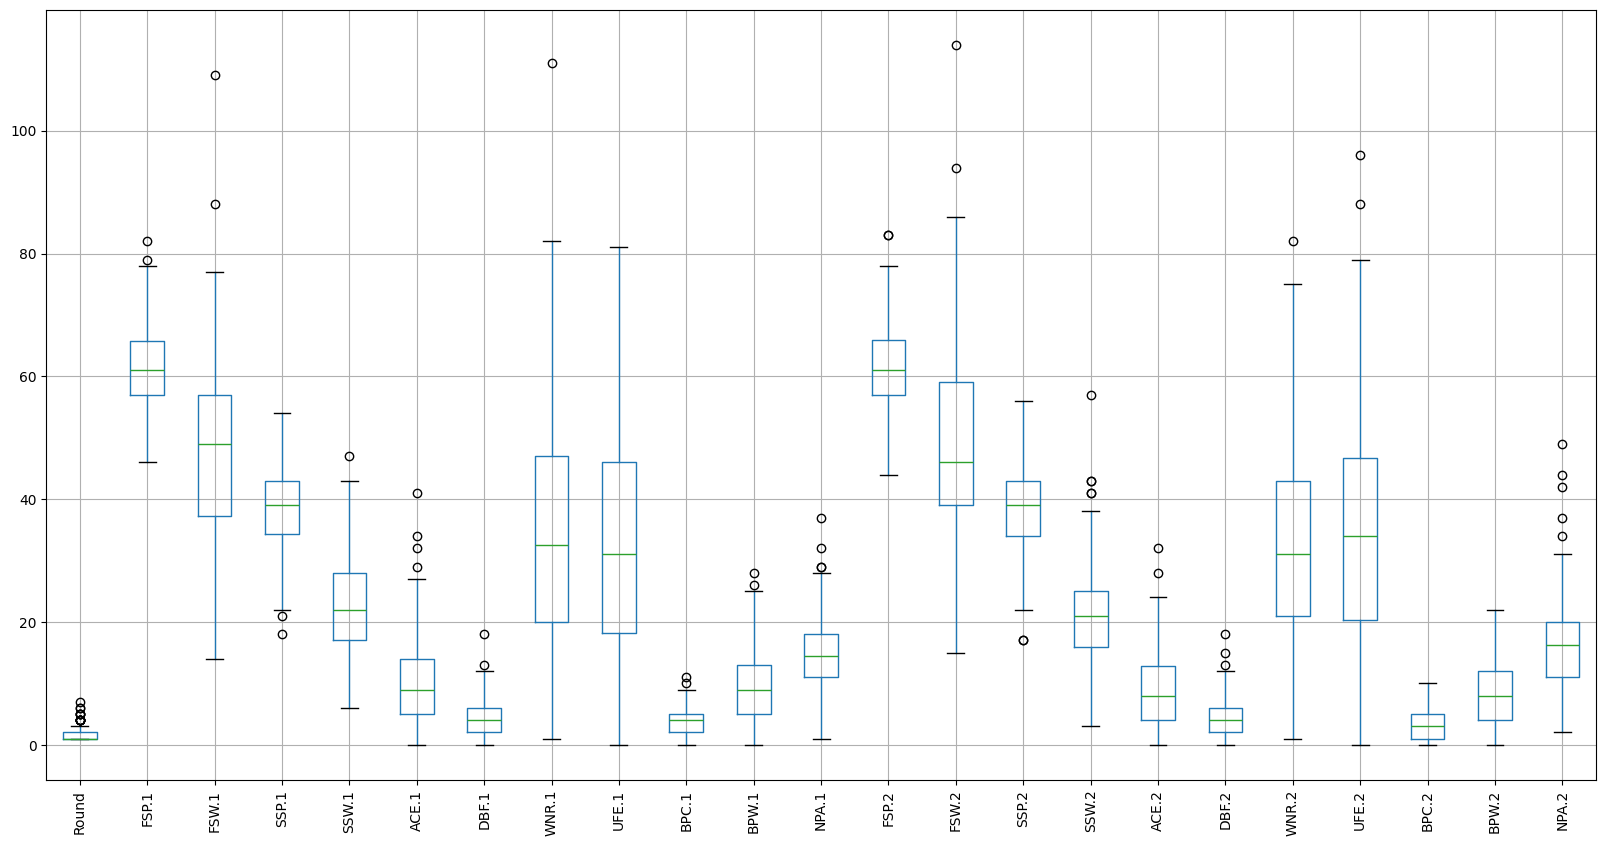

In [10]:
plt.figure(figsize=(20,10))
X.boxplot()
plt.xticks(rotation=90)
plt.show()

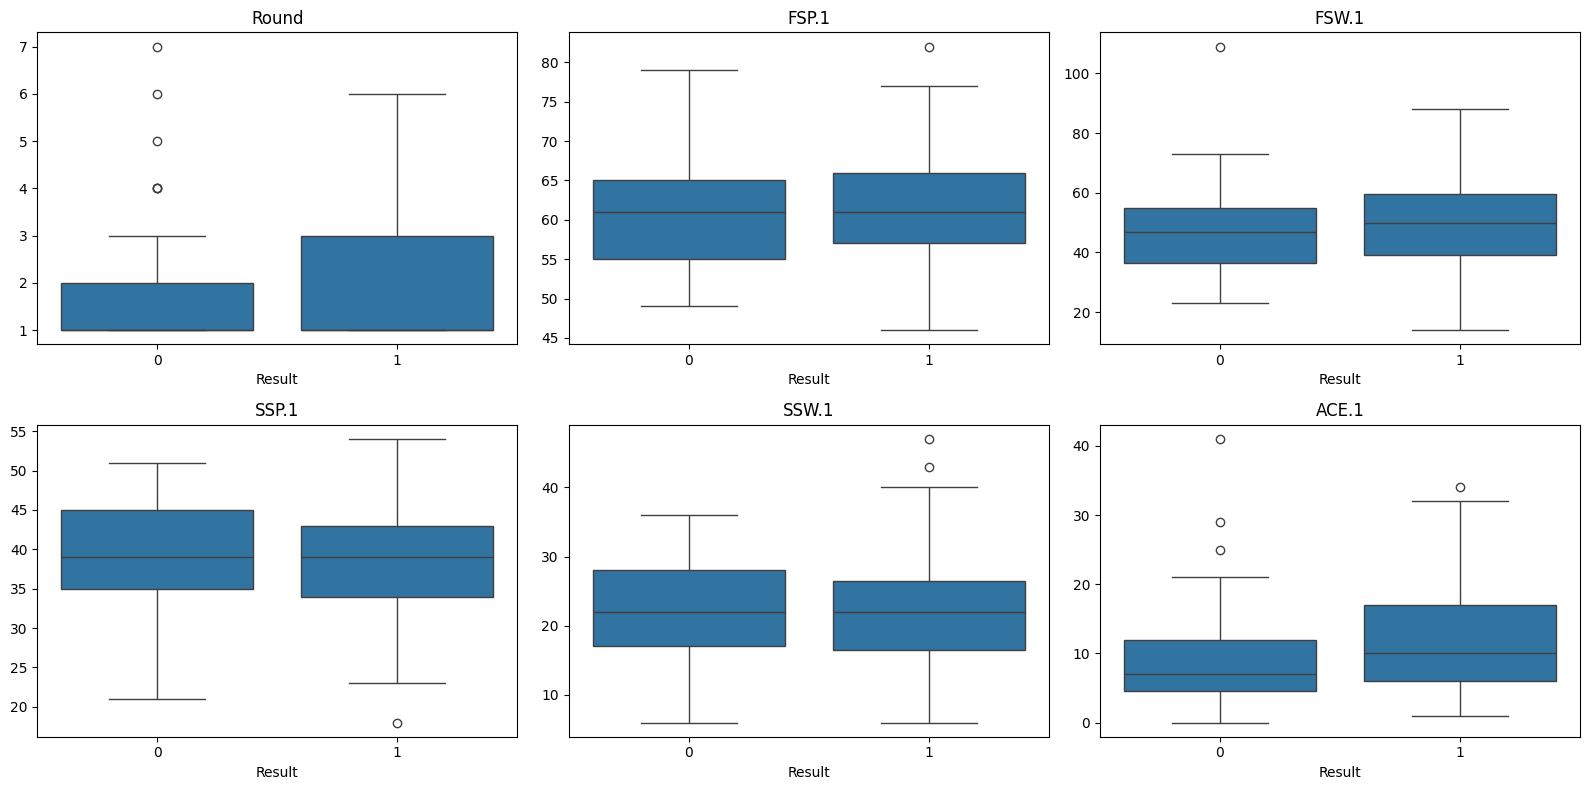

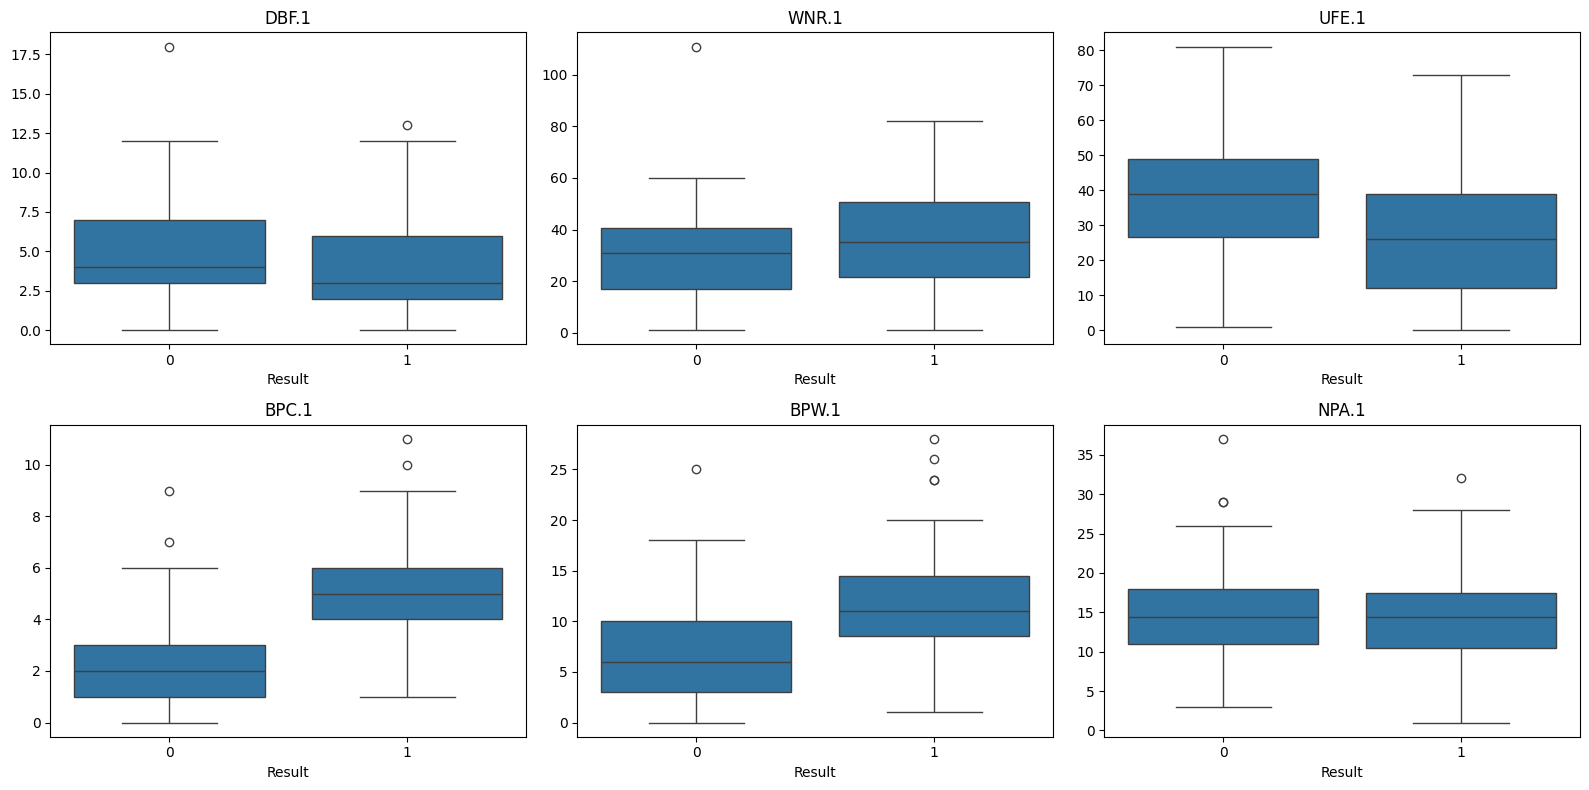

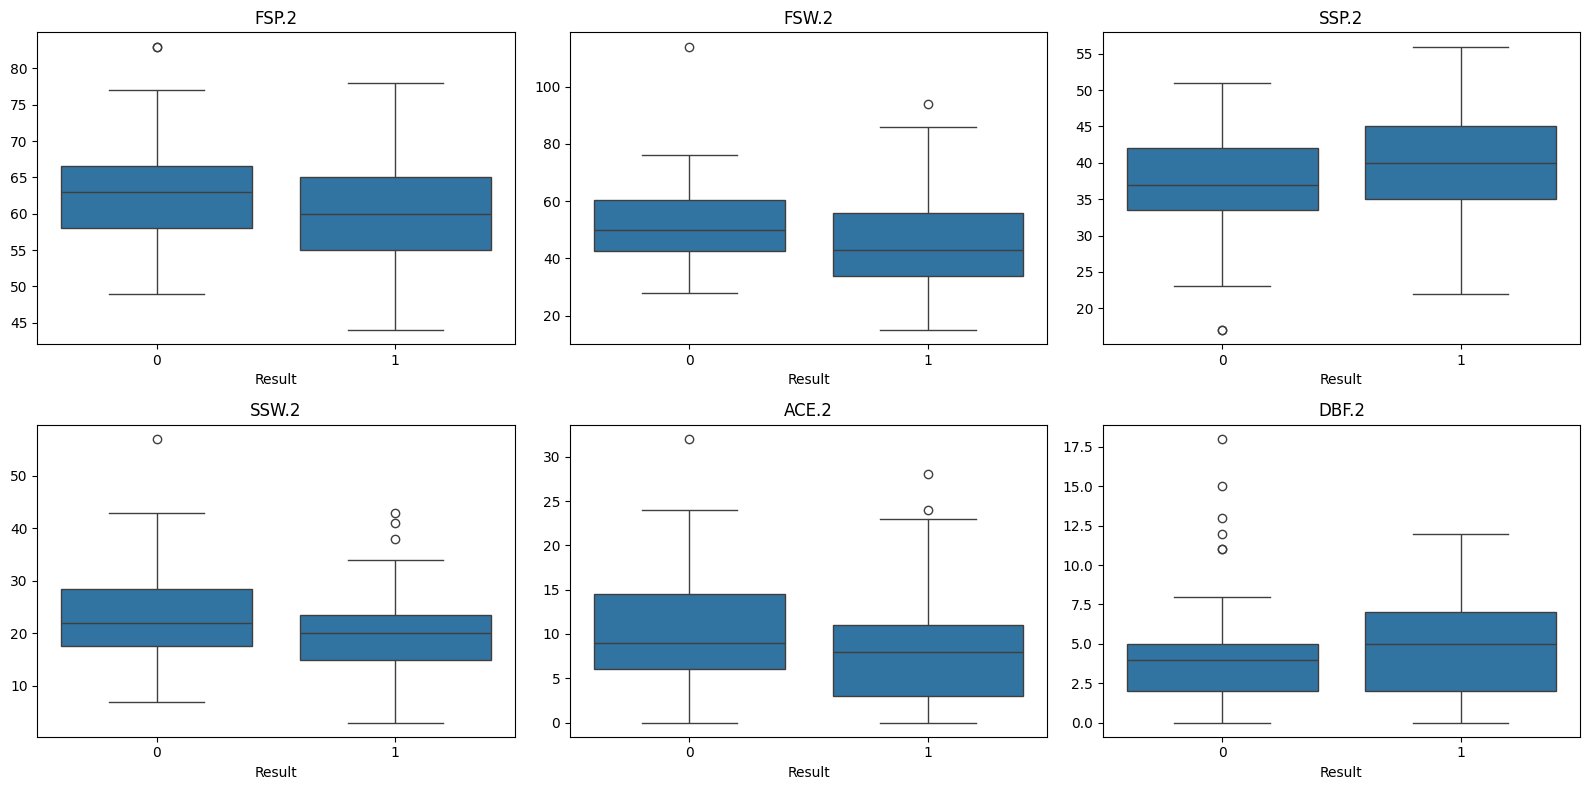

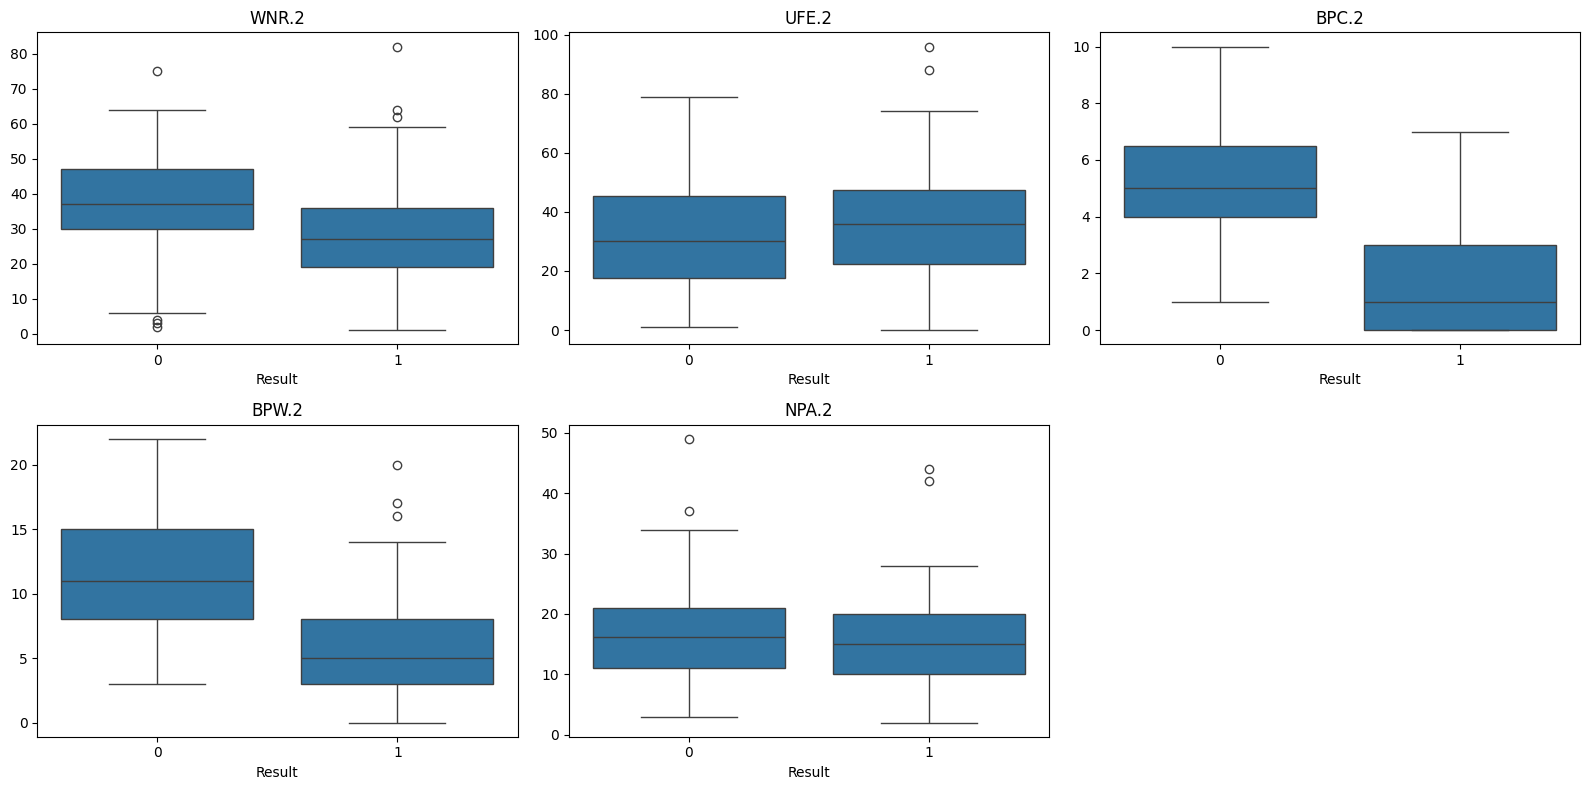

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

df_plot = X.copy()
df_plot["Result"] = y

cols = list(X.columns)
per_fig = 6
n_fig = math.ceil(len(cols) / per_fig)

for f in range(n_fig):
    subset = cols[f*per_fig:(f+1)*per_fig]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for ax, col in zip(axes, subset):
        sns.boxplot(data=df_plot, x="Result", y=col, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("Result")
        ax.set_ylabel("")

    # spegni assi vuoti
    for ax in axes[len(subset):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


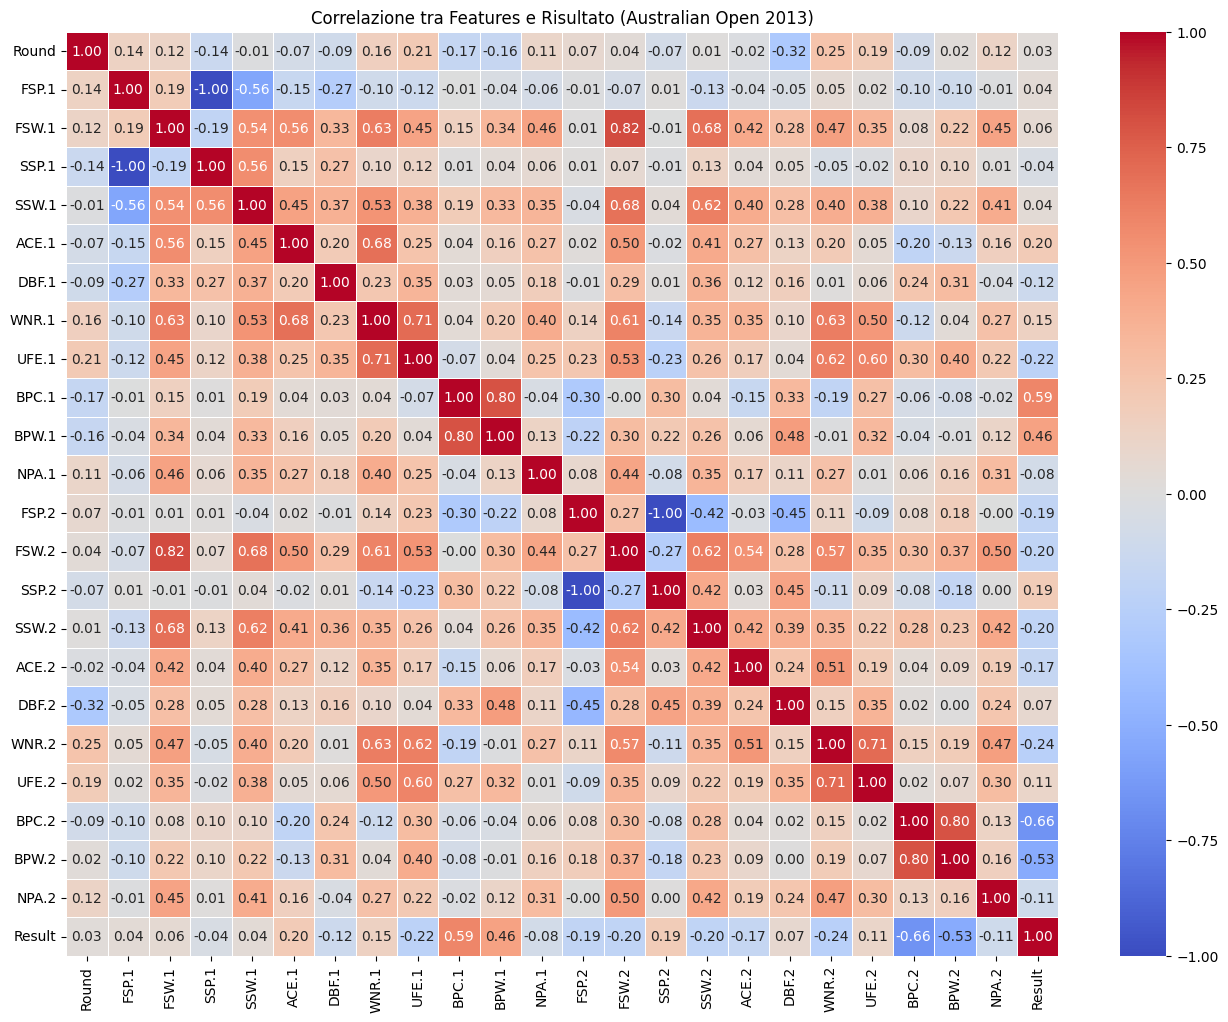

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creiamo un DataFrame temporaneo che unisce X e y
# Questo serve per vedere la correlazione tra le statistiche e la vittoria
df_corr = X.copy()
df_corr['Result'] = y

# 2. Calcoliamo la matrice di correlazione
# Usiamo il metodo di Pearson (standard)
corr_matrix = df_corr.corr()

# 3. Visualizziamo la Heatmap
plt.figure(figsize=(16, 12)) # La facciamo grande per leggere bene i nomi
sns.heatmap(corr_matrix, 
            annot=True,      # Mostra i numeri dentro i quadratini
            fmt=".2f",       # Arrotonda a 2 decimali
            cmap='coolwarm', # Colore: rosso (positivo), blu (negativo)
            linewidths=0.5)

plt.title('Correlazione tra Features e Risultato (Australian Open 2013)')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (100, 23)
Test shape: (26, 23)


In [14]:
#adestramento Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8461538461538461


[[10  2]
 [ 2 12]]


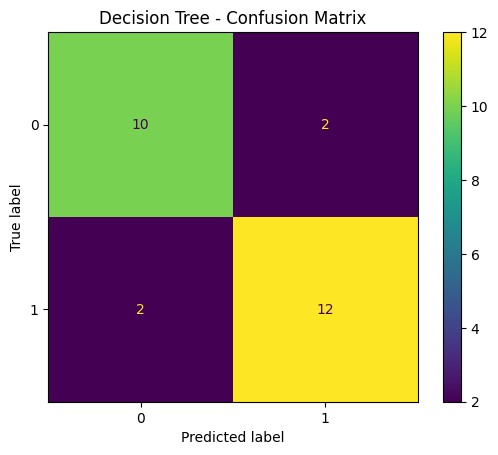

In [15]:
#confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [16]:
# Classification Report (Precision, Recall, F1)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.86      0.86      0.86        14

    accuracy                           0.85        26
   macro avg       0.85      0.85      0.85        26
weighted avg       0.85      0.85      0.85        26



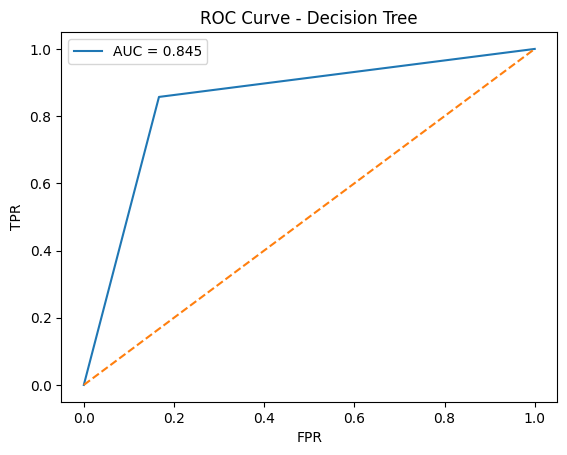

0.8452380952380952


In [17]:
#ROC Curve e AUC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = tree_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()
print(auc_score)

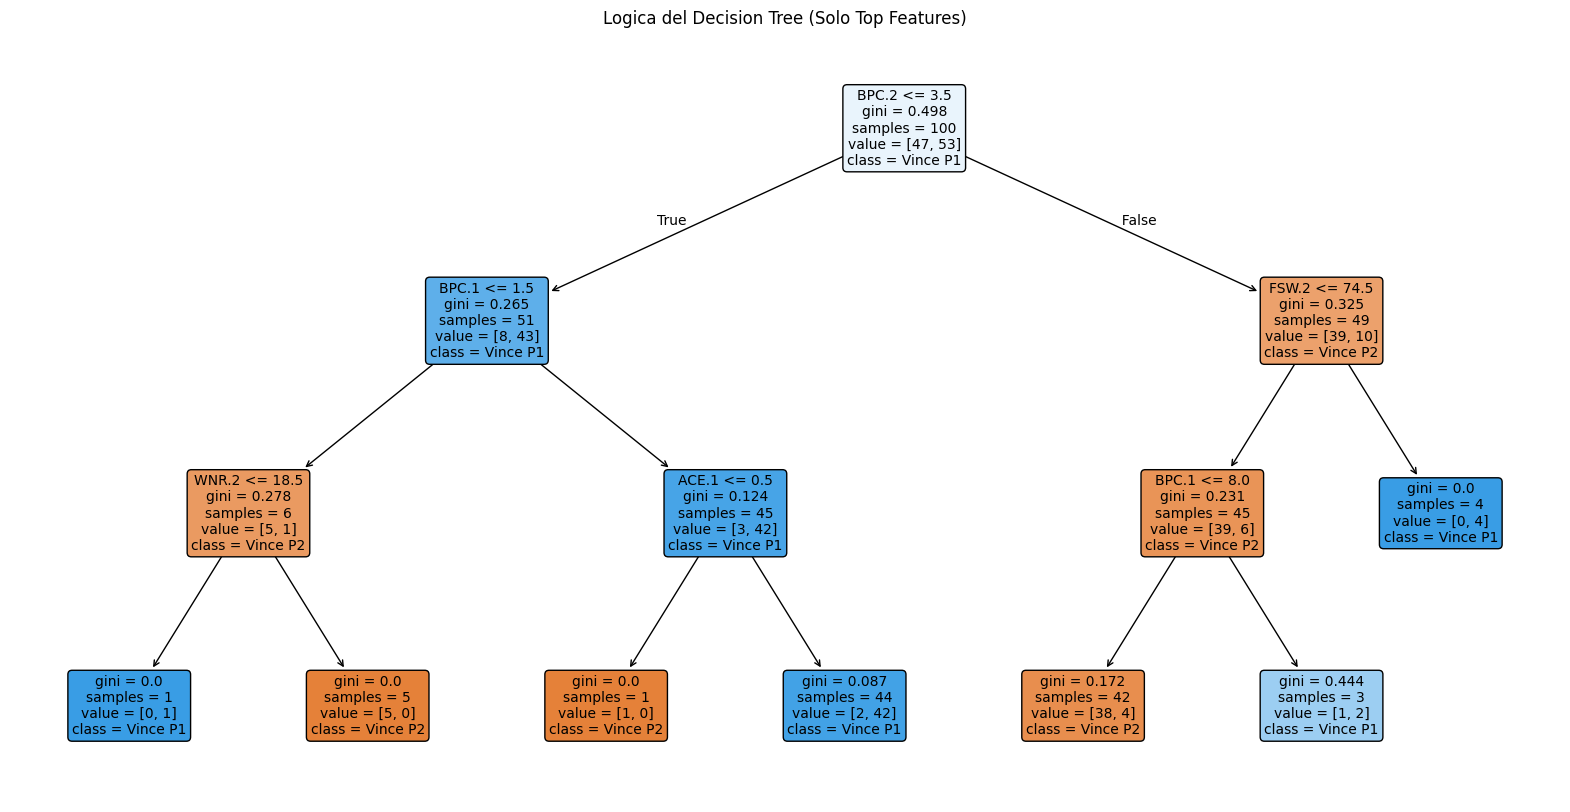

In [26]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model_top, 
          feature_names=X_train.columns, 
          class_names=['Vince P2', 'Vince P1'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Logica del Decision Tree (Solo Top Features)")
plt.show()

In [20]:
# versione con alcuni features che hanno maggior correlazione positiva e negativa con il target

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- 1. SELEZIONE TOP FEATURES ---
# Usiamo solo le variabili che la heatmap ci ha indicato come decisive
features_top = ['ACE.1', 'UFE.1', 'BPC.1', 'BPW.1', 'FSW.2', 'SSW.2', 'WNR.2', 'BPC.2', 'BPW.2']

# Creiamo il dataset filtrato
X_top = X[features_top].copy()


# --- 2. SPLIT DEI DATI ---
# Usiamo stratify=y come nel codice della tua collega per mantenere le proporzioni
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# --- 3. ADDESTRAMENTO DECISION TREE ---
# Usiamo max_depth=3 per evitare che l'albero diventi troppo complesso (overfitting)
tree_model_top = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model_top.fit(X_train, y_train)

# --- 4. PREDIZIONE E VALUTAZIONE ---
y_pred = tree_model_top.predict(X_test)
y_proba = tree_model_top.predict_proba(X_test)[:, 1]

print(f"=== RISULTATI MODELLO TOP FEATURES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



=== RISULTATI MODELLO TOP FEATURES ===
Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.92      0.86      0.89        14

    accuracy                           0.88        26
   macro avg       0.88      0.89      0.88        26
weighted avg       0.89      0.88      0.88        26



<Figure size 800x600 with 0 Axes>

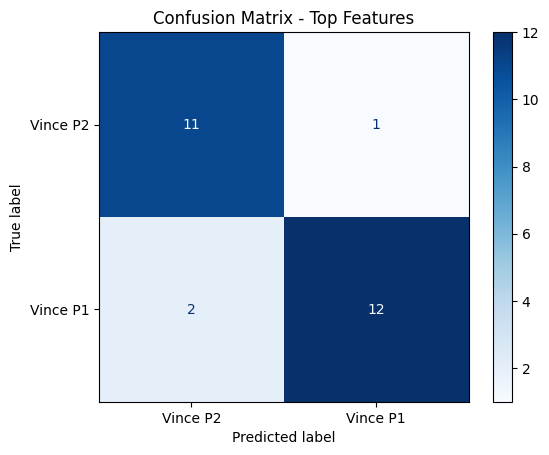

In [21]:
# --- 5. VISUALIZZAZIONE: CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Vince P2', 'Vince P1'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Top Features")
plt.show()



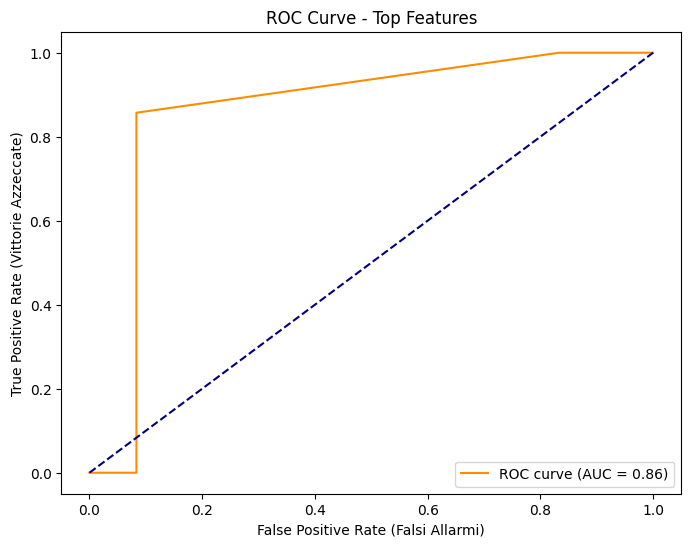

0.863095238095238


In [22]:
# --- 6. VISUALIZZAZIONE: CURVA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate (Falsi Allarmi)")
plt.ylabel("True Positive Rate (Vittorie Azzeccate)")
plt.title("ROC Curve - Top Features")
plt.legend(loc="lower right")
plt.show()
print(f"SCore finale: {auc_score}")


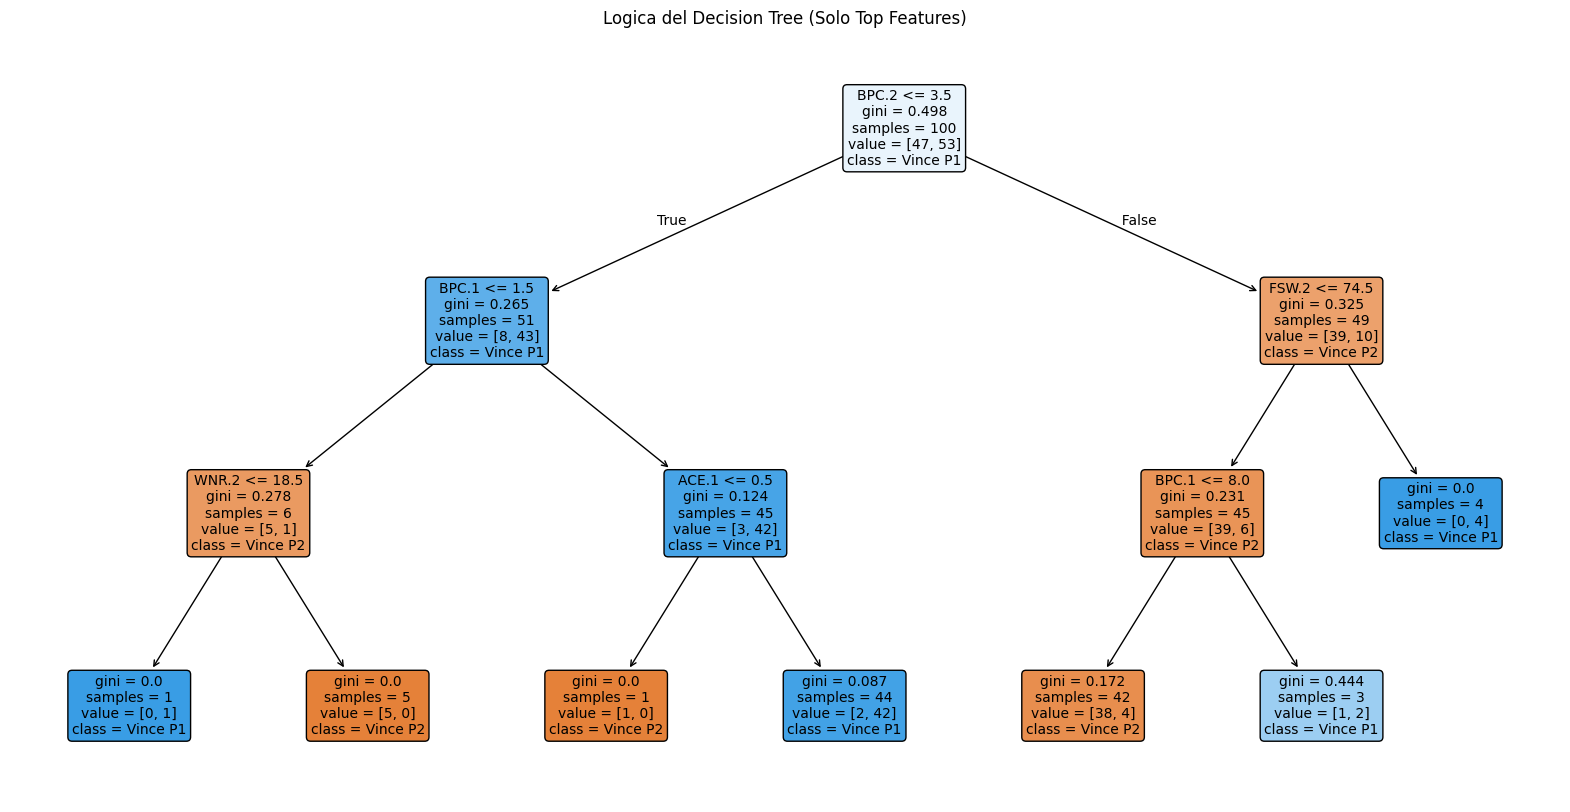

In [23]:
# --- 7. VISUALIZZAZIONE: L'ALBERO DECISIONALE ---
plt.figure(figsize=(20, 10))
plot_tree(tree_model_top, 
          feature_names=features_top, 
          class_names=['Vince P2', 'Vince P1'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Logica del Decision Tree (Solo Top Features)")
plt.show()

In [98]:
#proviamo a cambiare modello: Regressione Logistica

Accuratezza: 0.96
=== RISULTATI MODELLO LOGISTICO (TUTTE LE FEATURES) ===
Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.93      1.00      0.97        14

    accuracy                           0.96        26
   macro avg       0.97      0.96      0.96        26
weighted avg       0.96      0.96      0.96        26



<Figure size 800x600 with 0 Axes>

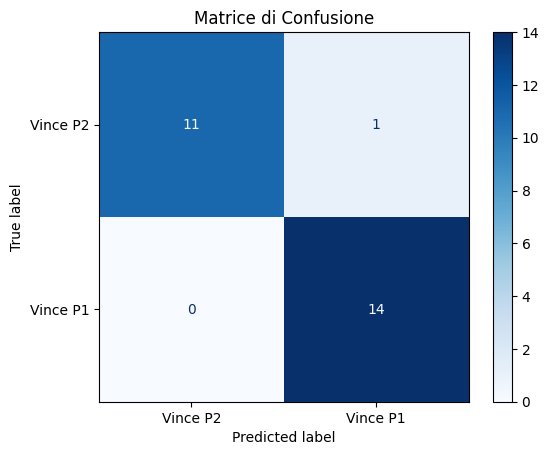

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#normalizziamo i dati 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. ADDESTRAMENTO ---
log_model= LogisticRegression()
log_model.fit(X_train_scaled, y_train)


# --- 2. PREDIZIONI ---
y_pred = log_model.predict(X_test_scaled)           # Predizione secca (0 o 1)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1] # Probabilità (da 0.0 a 1.0) per la Curva ROC

print(f"Accuratezza: {accuracy_score(y_test, y_pred):.2f}")

# --- 2. REPORT TESTUALE (Tutti gli score: F1, Recall, Precision) ---
print(f"=== RISULTATI MODELLO LOGISTICO (TUTTE LE FEATURES) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# - GRAFICO 1: CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
# Usiamo i nomi delle classi per renderlo leggibile
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Vince P2', 'Vince P1'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice di Confusione")
plt.show()



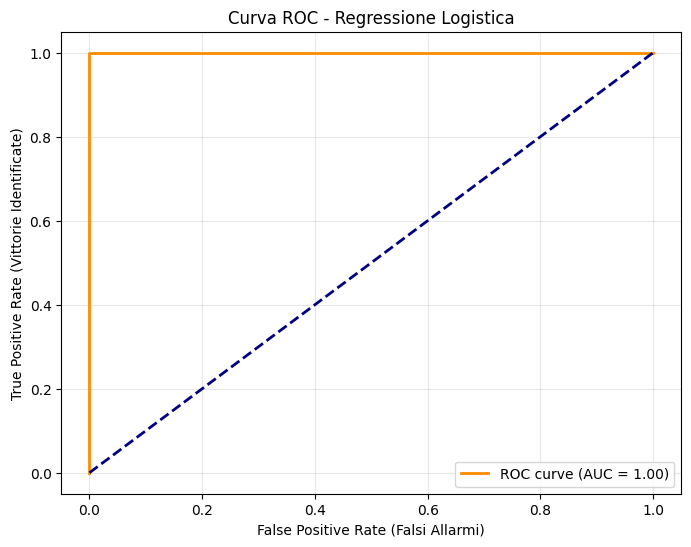

In [29]:
# --- 5. GRAFICO 2: CURVA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linea casuale
plt.xlabel('False Positive Rate (Falsi Allarmi)')
plt.ylabel('True Positive Rate (Vittorie Identificate)')
plt.title('Curva ROC - Regressione Logistica')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_11930/2521328276.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Feature', data=coefs, palette=colors)


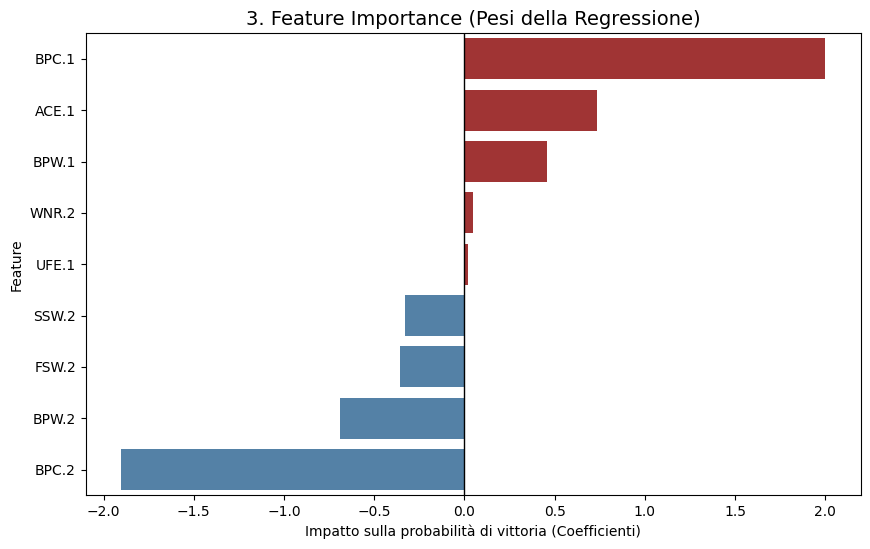

In [31]:
# --- 3. COEFFICIENTI (Il "cuore" della Regressione Logistica) ---
# Questo grafico DEVE esserci perché spiega il "perché" delle decisioni
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Peso': log_model.coef_[0]
}).sort_values(by='Peso', ascending=False)

plt.figure(figsize=(10, 6))
# Usiamo un barplot classico: Rosso = Aiuta P1, Blu = Aiuta P2
colors = ['firebrick' if x > 0 else 'steelblue' for x in coefs['Peso']]
sns.barplot(x='Peso', y='Feature', data=coefs, palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title("3. Feature Importance (Pesi della Regressione)", fontsize=14)
plt.xlabel("Impatto sulla probabilità di vittoria (Coefficienti)")
plt.show()

=== RISULTATI MODELLO LOGISTICO (FEATURES RISTRETTE) ===
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



<Figure size 600x500 with 0 Axes>

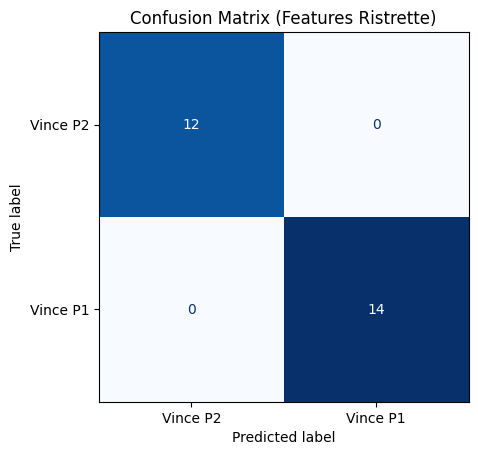

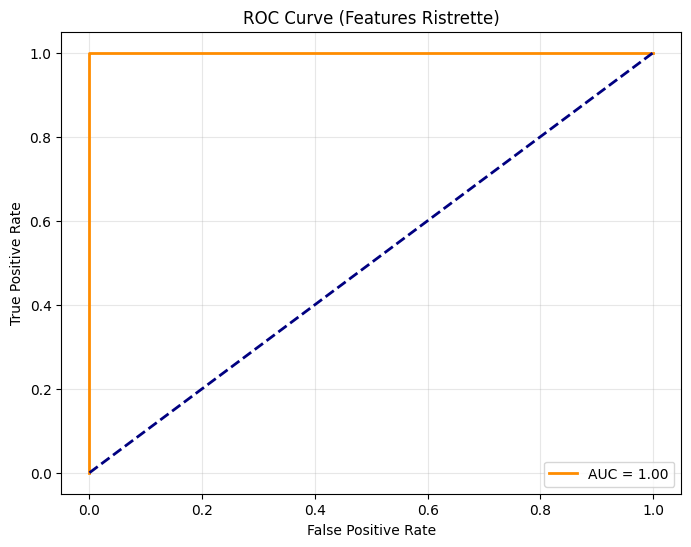

In [33]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# --- 1. SELEZIONE FEATURES "RISTRETTE" (Senza BPW per evitare multicollinearità) ---
features_reduced = ['ACE.1', 'UFE.1', 'BPC.1', 'FSW.2', 'SSW.2', 'WNR.2', 'BPC.2']
X_reduced = X[features_reduced].copy()

# --- 2. SPLIT & SCALING (Specifico per queste features) ---
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. ADDESTRAMENTO MODELLO ---
log_model_reduced = LogisticRegression()
log_model_reduced.fit(X_train_scaled, y_train)

# --- 4. PREDIZIONI ---
y_pred = log_model_reduced.predict(X_test_scaled)
y_proba = log_model_reduced.predict_proba(X_test_scaled)[:, 1]

# --- 5. REPORT TESTUALE ---
print(f"=== RISULTATI MODELLO LOGISTICO (FEATURES RISTRETTE) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 6. GRAFICO 1: CONFUSION MATRIX (Separato) ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Vince P2', 'Vince P1'])
disp.plot(cmap='Blues', values_format='d', colorbar=False)
plt.title("Confusion Matrix (Features Ristrette)")
plt.show()

# --- 7. GRAFICO 2: CURVA ROC (Separato) ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Features Ristrette)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()